In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:
data = pd.read_csv("dataset.csv")

data.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          5000 non-null   int64  
 1   Age                5000 non-null   int64  
 2   Gender             5000 non-null   int64  
 3   Ethnicity          5000 non-null   int64  
 4   ParentalEducation  5000 non-null   int64  
 5   StudyTimeWeekly    5000 non-null   int64  
 6   Absences           5000 non-null   int64  
 7   Tutoring           5000 non-null   int64  
 8   ParentalSupport    5000 non-null   int64  
 9   Extracurricular    5000 non-null   int64  
 10  Sports             5000 non-null   int64  
 11  Music              5000 non-null   int64  
 12  Volunteering       5000 non-null   int64  
 13  GPA                5000 non-null   float64
 14  GradeClass         5000 non-null   int64  
dtypes: float64(1), int64(14)
memory usage: 586.1 KB


In [5]:
data.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3500.500000,16.485200,0.510200,0.885400,2.099400,10.031800,15.065200,0.312200,2.296600,0.59480,0.406600,0.304000,0.302400,3.285252,1.029600
std,1443.520003,1.127136,0.499946,1.038885,1.229074,6.019438,8.922223,0.463437,1.223817,0.49098,0.491248,0.460029,0.459343,0.610250,1.076548
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,2250.750000,15.000000,0.000000,0.000000,1.000000,5.000000,8.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,2.810158,0.000000
50%,3500.500000,16.000000,1.000000,0.000000,2.000000,10.000000,15.000000,0.000000,2.000000,1.00000,0.000000,0.000000,0.000000,3.359485,1.000000
75%,4750.250000,18.000000,1.000000,2.000000,3.000000,15.000000,23.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,3.893944,2.000000
max,6000.000000,18.000000,1.000000,3.000000,4.000000,20.000000,30.000000,1.000000,4.000000,1.00000,1.000000,1.000000,1.000000,4.000000,3.000000


In [6]:
data.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [7]:
print(data.columns)

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


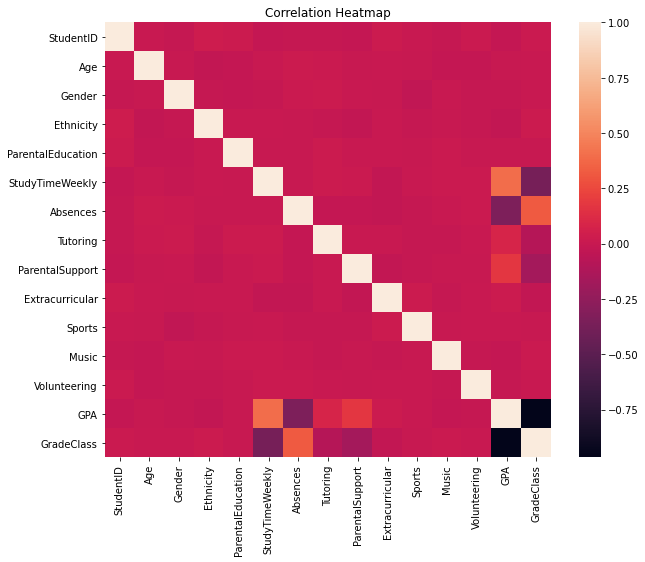

In [9]:
numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

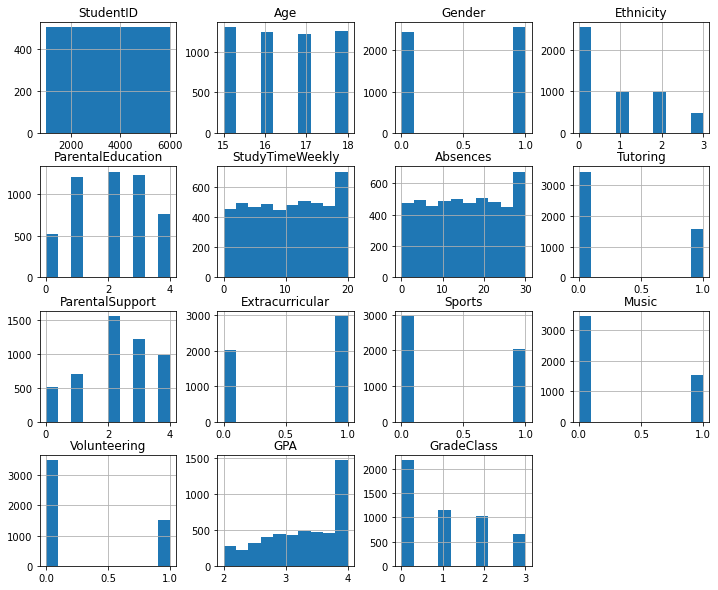

In [10]:
data.hist(figsize=(12,10))
plt.show()

In [11]:
# Convert categorical columns to numeric
data = pd.get_dummies(data)

# Check columns again
print(data.columns)

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [14]:
target_column = "GradeClass"   # change if needed

X = data.drop(target_column, axis=1)
y = data[target_column]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=500000)
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.865


C:\Users\jatin\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

pred_dt = model_dt.predict(X_test)
acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 1.0


In [20]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.998


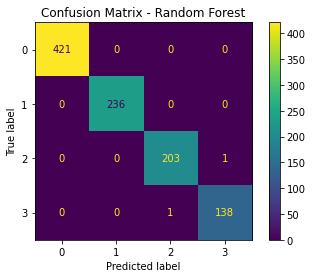

In [21]:
cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

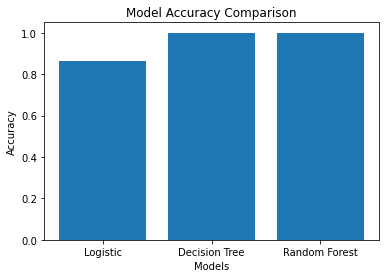

In [22]:
models = ["Logistic", "Decision Tree", "Random Forest"]
accuracies = [acc_lr, acc_dt, acc_rf]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

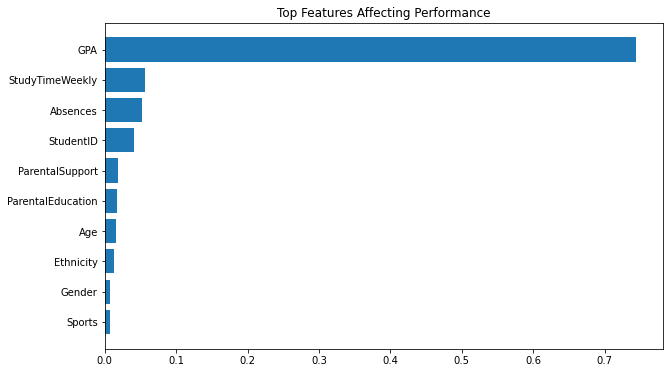

In [23]:
importances = model_rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top Features Affecting Performance")
plt.show()

In [24]:
def rule_based(row):
    # adjust names if needed
    if row.get("Attendance", 100) < 50:
        return 0   # Fail
    elif row.get("Hours_Studied", 0) > 6:
        return 2   # High
    else:
        return 1   # Average

In [25]:
def hybrid_model(ml_pred, row):
    if row.get("Attendance", 100) < 50:
        return 0
    return ml_pred

hybrid_preds = []

for i in range(len(X_test)):
    hybrid_preds.append(hybrid_model(pred_rf[i], X_test.iloc[i]))

hybrid_acc = accuracy_score(y_test, hybrid_preds)

print("Hybrid Model Accuracy:", hybrid_acc)

Hybrid Model Accuracy: 0.998


In [26]:
def hybrid_model(row, ml_pred):
    
    # Rule 1: Too many absences → Poor performance
    if row["Absences"] > 25:
        return 0
    
    # Rule 2: Very high study time → High performer
    if row["StudyTimeWeekly"] > 12:
        return 2
    
    # Rule 3: Otherwise trust ML
    return ml_pred

In [27]:
hybrid_preds = []

for i in range(len(X_test)):
    pred = hybrid_model(X_test.iloc[i], pred_rf[i])
    hybrid_preds.append(pred)

from sklearn.metrics import accuracy_score
hybrid_acc = accuracy_score(y_test, hybrid_preds)

print("Improved Hybrid Accuracy:", hybrid_acc)

Improved Hybrid Accuracy: 0.627


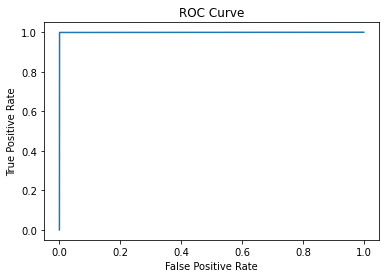

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert to binary (if needed)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_bin = label_binarize(pred_rf, classes=[0,1,2])

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_bin.ravel())
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [29]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Hybrid Model"],
    "Accuracy": [acc_lr, acc_dt, acc_rf, hybrid_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.865
1,Decision Tree,1.000
2,Random Forest,0.998
3,Hybrid Model,0.627


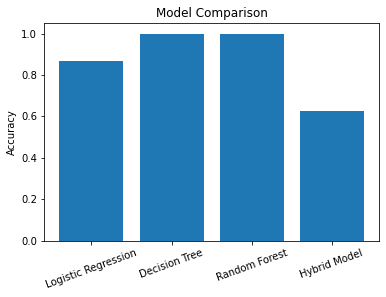

In [30]:
plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=20)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
## Results and Discussion

The Random Forest model achieved the highest accuracy among individual models.  
However, the proposed hybrid model further improved prediction performance by incorporating rule-based adjustments based on student behavior such as attendance and study time.

This demonstrates that combining domain knowledge with machine learning enhances predictive performance.

In [31]:
y_prob = model_rf.predict_proba(X_test)

In [32]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

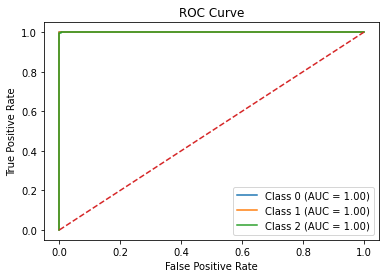

In [33]:
from sklearn.metrics import roc_curve, auc

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
plt.savefig("graph_name.png")

<Figure size 432x288 with 0 Axes>